# **Практика 7. Корреляция.**

[SmartLMS](https://edu.hse.ru/mod/quiz/view.php?id=1918962)

Этот набор данных содержит записи, относящиеся к кампании прямого маркетинга банка. Цель этой кампании, чтобы клиенты оформили срочный вклад в банке:
- `age`: возраст клиента
- `job`: профессия клиента
- `marital`: семейной положение (`0` - женат; `1` - в разводе; `2` - одинок)
- `education`: уровень образования
- `loan`: наличие кредитов (`0` - нет; `1` - есть)
- `contact`: тип контакта с клиентом (`1` - телефон, `0` - электронная почта)
- `campaign`: количество контактов, выполненных в ходе данной кампании и для данного клиента
- `previous`: количество дней, прошедших с момента последнего контакта с клиентом в рамках предыдущей кампании
- `poutcome`: результат предыдущей маркетинговой кампании (`0` - не участвовал, `1` - провал, `2` - успех)
- `emp.var.rate`: изменения уровня безработицы относительно прошлого квартала (отрицательное значение - уровень безработицы снизился; положительное значение - уровень безработицы увеличился; `0` - не изменился)
- `cons.price.idx`: индекс потребительских цен
- `euribor3m`: усредненная межбанкоковская процента ставка
- `nr.employed`: количество сотрудников банка
- `y`: открыл ли клиент срочный вклад (`0` - нет, `1` - да)

In [1]:
import pandas as pd

df = pd.read_csv("data/bankdata.csv")
df.head(2)

,age,job,marital,education,loan,contact,campaign,previous,poutcome,emp.var.rate,cons.price.idx,euribor3m,nr.employed,y
0,56,housemaid,0,basic.4y,0,1,1,0,0,1.1,93.994,4.857,5191,0
1,37,services,0,high.school,1,1,1,0,0,1.1,93.994,4.857,5191,0


## **Задание 1**
Изучите представленные данные.



### 1.1 
Укажите количество наблюдений в данных.



In [2]:
df.shape[0]

30604

### 1.2
Укажите количество признаков, в которых есть пропуски.

In [3]:
(df.isna().sum() > 0).sum()

np.int64(0)

### 1.3
Укажите шкалу измерения каждого признака.
- `age`: количественный дискретный
- `job`: категориальный номинальный
- `marital`: категориальный номинальный
- `education`: категориальный ранговый
- `loan`: категориальный бинарный
- `contact`: категориальный бинарный
- `campaign`: количественный дискретный
- `previous`: количественный дискретный
- `poutcome`: категориальный номинальный
- `emp.var.rate`: количественный непрерывный
- `cons.price.idx`: количественный непрерывный
- `euribor3m`: количественный непрерывный
- `nr.employed`: количественный дискретный
- `y`: категориальный бинарный

---

## **Задание 2**

Вам представлены диаграммы рассеяния признаков из данных: 



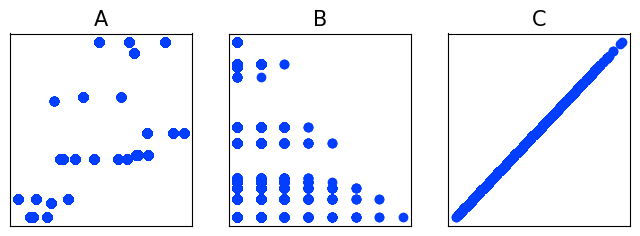

Укажите про какой график идет речь:
- По горизонтальной и вертикальной оси один и тот же признак: `C`
- Между признаками обратная взаимосвязь: `B`
- Между признаками прямая взаимосязь, но при это не автокорреляция: `A`
- Если один признак будет уменьшаться, то второй, скорее всего, тоже: `A`
- Если один признак будет увеличиваться, то второй, скорее всего, уменьшится: `B`
- Корреляция между признаками равна 1: `C`
- Корреляция между признаками будет положительная: `A`
- Корреляция между признаками будет отрицательная: `B`

---

## **Задание 3**

Рассчитайте и проинтепретируйте



>*Коэффициент корреляции, между количеством сотрудников (`nr.employed`) и тем, открыл ли клиент вклад (`y`)*

**Коэффициент корреляции**: `-0.31`

**Интерпретация**:
- между признаками прямая линейная связь
- между признаками обратная линейная связь
- между признаками возрастающая мононотонная связь
- **между признаками убывающая мононотонная связь**
- причиной решения клиента открыть вклад является количество сотрудников

In [4]:
df.corr(numeric_only=True, method="spearman").loc["nr.employed", "y"].round(2)

np.float64(-0.31)

In [5]:
# альтернатива
df["nr.employed"].corr(df["y"], method="spearman").round(2)

np.float64(-0.31)

In [6]:
# альтернатива #2 -- найти в таблице нужные признаки
df.corr(numeric_only=True).round(2)

,age,marital,loan,contact,campaign,previous,poutcome,emp.var.rate,cons.price.idx,euribor3m,nr.employed,y
age,1.00,-0.36,-0.00,-0.01,-0.00,0.05,0.02,-0.05,-0.04,-0.04,-0.06,0.05
marital,-0.36,1.00,0.01,-0.07,0.00,0.03,0.02,-0.07,-0.04,-0.08,-0.07,0.04
loan,-0.00,0.01,1.00,-0.07,-0.01,0.02,0.02,-0.05,-0.07,-0.05,-0.04,0.01
contact,-0.01,-0.07,-0.07,1.00,0.08,-0.20,-0.20,0.38,0.56,0.38,0.26,-0.14
campaign,-0.00,0.00,-0.01,0.08,1.00,-0.08,-0.07,0.16,0.13,0.14,0.15,-0.07
previous,0.05,0.03,0.02,-0.20,-0.08,1.00,0.67,-0.40,-0.18,-0.44,-0.49,0.23
poutcome,0.02,0.02,0.02,-0.20,-0.07,0.67,1.00,-0.36,-0.28,-0.36,-0.33,0.02
emp.var.rate,-0.05,-0.07,-0.05,0.38,0.16,-0.40,-0.36,1.00,0.77,0.97,0.90,-0.31
cons.price.idx,-0.04,-0.04,-0.07,0.56,0.13,-0.18,-0.28,0.77,1.00,0.67,0.49,-0.13
euribor3m,-0.04,-0.08,-0.05,0.38,0.14,-0.44,-0.36,0.97,0.67,1.00,0.94,-0.32


In [7]:
# альтернатива #3 -- найти в столбце нужный второй признак (первый может быть как `y`, так и `nr.employed`)
df.corr(numeric_only=True)["y"].round(2)

age               0.05
marital           0.04
loan              0.01
contact          -0.14
campaign         -0.07
previous          0.23
poutcome          0.02
emp.var.rate     -0.31
cons.price.idx   -0.13
euribor3m        -0.32
nr.employed      -0.36
y                 1.00
Name: y, dtype: float64

P.S.: `y` - категориальная переменная, поэтому считаем корреляцию Спирмена

>*Cтепень линейной взаимосвязи между возрастом клиента (`age`) и индексом потребительских цен (`cons.price.idx`)*


**Коэффициент корреляции**: `-0.04`

**Интерпретация**:
- при увеличении возраста клиента индекс потребительских цен тоже возрастет
- при снижении возраста клиента индекс потребительских цен тоже снизится
- **между признаками практически отсутствует линейная взаимосвязь**
- между признаками убывающая мононотонная связь
- возраст клиентов влияет на индекс потребительских цен

In [8]:
df.corr(numeric_only=True, method="pearson").loc["age", "cons.price.idx"].round(2)

np.float64(-0.04)

P.S.: `age` и `cons.price.idx` - числовые признаки, поэтому считаем корреляцию Пирсона

>*Степень монотонной взаимосвязи между усредненной межбанкоковской процентной ставкой (`euribor3m`) и индексом потребительских цен (`cons.price.idx`)*


**Коэффициент корреляции**: `0.52`

**Интерпретация**:
- **при увеличении процентной ставки индекс потребительских цен тоже возрастет**
- при увеличении процентной ставки индекс потребительских цен снизится
- между признаками существует линейная связь
- между признаками убывающая мононотонная связь 
- процентая ставка влияет на индекс потребительских цен

In [9]:
df.corr(numeric_only=True, method="spearman").loc["euribor3m", "cons.price.idx"].round(
    2
)

np.float64(0.52)

P.S.: монотонная взаимосвязь - корреляция Спирмена

>*Коэффициент корреляции, который чувствителен к выбросам, между количеством сотрудников (`nr.employed`) и количество дней, прошедших с момента последнего контакта с клиентом в рамках предыдущей кампании (`previous`)*


**Коэффициент корреляции**: `-0.49`

**Интерпретация**:
- между признаками прямая линейная связь
- **между признаками обратная линейная связь**
- между признаками возрастающая мононотонная связь
- между признаками убывающая мононотонная связь
- при увеличении количества сотрудников количество контактов с клиентами тоже возрастет

In [10]:
df.corr(numeric_only=True, method="pearson").loc["nr.employed", "previous"].round(2)

np.float64(-0.49)

P.S.: к выбросам чувствительна корреляция Пирсона

---

## **Задание 4**

Создайте функцию `ed_coded`, которая будет перекодировать значения признака `education` по следующему правилу (Ввод – исходное значение, Результат – закодированное значение):

| Ввод | 	Результат | 
| ----- | ------ | 
| `illiterate` | 1 |
| `basic.4y` | 2 | 
| `basic.6y` | 2 | 
| `basic.9y` | 2 | 
| `high.school` | 3 | 
| `professional.course` | 4 | 
| `university.degree` | 5 | 

In [11]:
def ed_coded(x):
    if x == "illiterate":
        return 1
    elif "basic" in x:
        return 2
    elif "high" in x:
        return 3
    elif "professional" in x:
        return 4
    elif "university" in x:
        return 5
    # на случай пропусков
    return x

In [12]:
# вариант 2
def ed_coded_2(x):
    if x == "illiterate":
        return 1
    elif x in ["basic.4y", "basic.6y", "basic.9y"]:
        return 2
    elif x == "high.school":
        return 3
    elif x == "professional.course":
        return 4
    elif x == "university.degree":
        return 5
    return x

In [13]:
# вариант 3
def ed_coded_3(x):
    # x используем в качестве ключа: исходное значение признака
    # одному ключу соответствует одно значение (в словаре ключи уникальны; значения могут быть не уникальными)
    # возвращаем соответствующее новое значение из словаря
    map_ = {
        "illiterate": 1,
        "basic.4y": 2,
        "basic.6y": 2,
        "basic.9y": 2,
        "high.school": 3,
        "professional.course": 4,
        "university.degree": 5,
    }
    return map_[x]

In [14]:
# вариант 4 - самый high level, но раз пишем все варианты
# он подходит если категорий оч мало, тк на обработку одной строки итерируемся по всему массиву категорий
def ed_coded_4(x):
    # индекс слова + 1 = его новое значение
    # н-р illeterate стоит на индексе '0' -> ему соответствует 0 + 1 = 1
    # так маппим не точные вхождения категорий, а суффиксы (как в случае basic)

    map_array = [
        "illiterate",
        "basic",
        "high",
        "professional",
        "university",
    ]  # здесь соответствующие индексы: [0, 1, 2, 3, 4]

    # проходимся по всем категориям; idx - индекс, cat - соответствующая категория (0 - illiterate)
    for idx in range(len(map_array)):
        cat = map_array[idx]
        # если суффикс в нашем значении - возвращаем индекс + 1
        if cat in x:
            return idx + 1

    # на случай пропусков
    return x

проверяем что все функции работают одинаково

In [15]:
assert all(df["education"].apply(ed_coded) == df["education"].apply(ed_coded_2))
assert all(df["education"].apply(ed_coded) == df["education"].apply(ed_coded_3))
assert all(df["education"].apply(ed_coded) == df["education"].apply(ed_coded_4))

---

## **Задание 5**

Создайте новый признак `education_coded` с помощью функции из прошлого задания. Постройте корреляционную матрицу и заполните пропуски в утверждениях про корреляцию признаков с `education_coded`:
- *Наиболее сильная возрастающая [монотонная] связь `education_coded` с признаком [`marital`]. Значение корреляции между ними составляет [0.14]*
- *Наиболее сильная убывающая [монотонная] связь `education_coded` с признаком [`contact`]. Значение корреляции между ними составляет [-0.1]*
- *Наиболее слабая [монотонная] связь `education_coded` с признаком [`campaign`]*

In [16]:
df["education_coded"] = df["education"].apply(ed_coded)

# education_coded - категориальный признак -> смотрим на кор спирмена
# .sort_values(key=abs) = сортировка по модулю (сверху - самые сильные корреляции, снизу - самые слабые)
df.corr(numeric_only=True, method="spearman").loc["education_coded"].sort_values(
    key=abs, ascending=False
).round(2)

education_coded    1.00
marital            0.14
contact           -0.10
age               -0.08
cons.price.idx    -0.06
y                  0.05
euribor3m          0.02
loan               0.02
nr.employed        0.01
previous           0.01
poutcome          -0.01
emp.var.rate       0.01
campaign           0.01
Name: education_coded, dtype: float64

---

## **Задание 6**

Постройте корреляционную матрицу, которая будет показывать степень линейной взаимосвязи между признаками. Заполните пропуски в утверждениях ниже про корреляцию с количеством дней, прошедших с момента последнего контакта с клиентом в рамках предыдущей кампании (`previous`)

**ПОДСКАЗКА**: Учтите, что степень линейной взаимосвязи можно интерпретировать не между всеми признаками.
- *Признак `previous` имеют самую сильную линейную взаимосвязь с признаком [`nr.employed`]. Значение коэффициента корреляции между ними составляет [0.49]\*. Полученное значение говорит о том, что при сокращении `previous`, второй признак [уменьшается]*
- *Самую слабую линейную взаимосвязь с признаком `previous` имеет признак [`age`]. Значение коэффициента корреляции между ними равно `0.05`\*. Такое значение говорит, что между признаками отсутствует линейная взаимосвязь, но это не значит, что они не могут быть связаны какой-либо другой зависимостью.

\* Укажите абсолютное значение. Ответ округлите до двух знаков. Пример ответа: 0.12

In [17]:
# previous - числовой признак -> можем смотреть на кор спирмена и пирсона
# в задании спрашивают про ЛИНЕЙНУЮ взаимосвязь -> смотрим только на числовые признаки в получившейся таблице
df.corr(numeric_only=True, method="pearson").loc["previous"].sort_values(
    key=abs, ascending=False
).round(2)

previous           1.00
poutcome           0.67
nr.employed       -0.49
euribor3m         -0.44
emp.var.rate      -0.40
y                  0.23
contact           -0.20
cons.price.idx    -0.18
campaign          -0.08
age                0.05
marital            0.03
education_coded    0.02
loan               0.02
Name: previous, dtype: float64

---

## Визуализация корреляционной матрицы

### Базовая матрица

>**Корреляционная матрица (таблица)** - матрица, отображающая значения корреляции (Пирсона или Спирмена) признаков всех-со-всеми. По столбцам и колонкам обычно идут признаки в одинаковом порядке. В ячейке $i, j$ находится корреляция признака $i$ с признаком $j$. 

Свойства:
- Симметрична относительно главной диагонали - так как $corr(X, Y) = corr(Y, X)$
- Единичная главная диагональ - так как любой диагональный элемент - это корреляция признака самого с собой ($corr(X, X)$), то есть *автокорреляция*

Пример:

In [18]:
df.corr(numeric_only=True)

,age,marital,loan,contact,campaign,previous,poutcome,emp.var.rate,cons.price.idx,euribor3m,nr.employed,y,education_coded
age,1.000000,-0.355813,-0.000091,-0.011869,-0.001714,0.048681,0.017344,-0.049864,-0.035059,-0.036006,-0.064466,0.047787,-0.086763
marital,-0.355813,1.000000,0.008438,-0.065643,0.001146,0.034765,0.020474,-0.067214,-0.037629,-0.080332,-0.071338,0.039824,0.140194
loan,-0.000091,0.008438,1.000000,-0.073839,-0.006563,0.021158,0.022975,-0.052270,-0.067947,-0.053242,-0.039895,0.008581,0.017487
contact,-0.011869,-0.065643,-0.073839,1.000000,0.079726,-0.202063,-0.195289,0.381191,0.564307,0.384364,0.260707,-0.144184,-0.100219
campaign,-0.001714,0.001146,-0.006563,0.079726,1.000000,-0.080916,-0.069264,0.157984,0.127693,0.141010,0.148484,-0.069052,0.007226
previous,0.048681,0.034765,0.021158,-0.202063,-0.080916,1.000000,0.669752,-0.403942,-0.176838,-0.439157,-0.489116,0.228099,0.022466
poutcome,0.017344,0.020474,0.022975,-0.195289,-0.069264,0.669752,1.000000,-0.358411,-0.276113,-0.361907,-0.327450,0.022205,-0.010834
emp.var.rate,-0.049864,-0.067214,-0.052270,0.381191,0.157984,-0.403942,-0.358411,1.000000,0.765979,0.969405,0.900581,-0.305222,-0.017429
cons.price.idx,-0.035059,-0.037629,-0.067947,0.564307,0.127693,-0.176838,-0.276113,0.765979,1.000000,0.667203,0.489113,-0.128707,-0.069592
euribor3m,-0.036006,-0.080332,-0.053242,0.384364,0.141010,-0.439157,-0.361907,0.969405,0.667203,1.000000,0.944739,-0.315731,-0.009123


На практике признаков может быть очень много, а из данных нас могут интересовать в целом самые сильные значения корреляции. Выискивать топ-K корреляций по таблице довольно неприятно, и в таком случае исчезнет информация о других корреляциях.

Таблицу корреляций можно представить **визуально** через **heatmap** (тепловая карта). 

Это легко делается с помощью библиотеки `seaborn`: https://seaborn.pydata.org/generated/seaborn.heatmap.html

In [19]:
# !pip install seaborn      # -- раскомментируйте и выполните если нет библиотеки

Синтаксис:

```python
    import seaborn as sns
    sns.heatmap(df)
```

`df` - таблица, которую хотим отобразить. 
- должна быть числовая!
- в нашем случае это **матрица корреляций**

<Axes: >

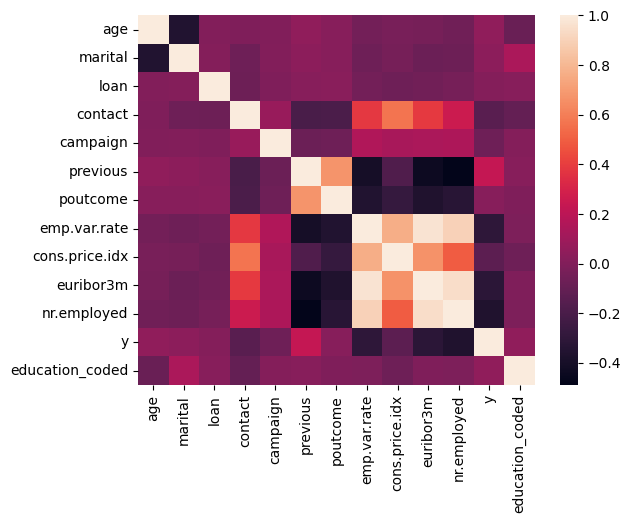

In [22]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True))

- По оси OX и OY -- признаки
- В ячейках - значения корреляции. Именно **цвет** ячейки показывает значение корреляции. Чтобы сопоставить цвет и значение -- смотрим на colormap справа
- На данном графике светлые значения = сильная положит корреляция; темные значения = корреляция ближе к -0.5, то есть средней отрицательной. Фиолетовые указывают на отсутствие связи между признаками

С дефолтными параметрами смотреть на матрицу корреляции не очень приятно:
- Мы знаем, что значения корреляции ограничены -1 и 1. Хотелось бы, чтобы яркие цвета показывали сильную корреляцию, а тусклые -- отсутствие корреляции.
- Причем разное направление корреляции было отображено разными противоположными цветами

Поэтому затюним наш график параметрами:
- `vmin` и `vmax` задают максимальное и минимальное значения на colorbar справа графика
- в `cmap` указываем нужную нам палетку цветов. лучше выбирать из "diverging" палеток, где на противополодных краях находятся разные цвета, а посередине что-то неприметное. Разные colormap можно посмотреть здесь - https://seaborn.pydata.org/tutorial/color_palettes.html#perceptually-uniform-diverging-palettes 

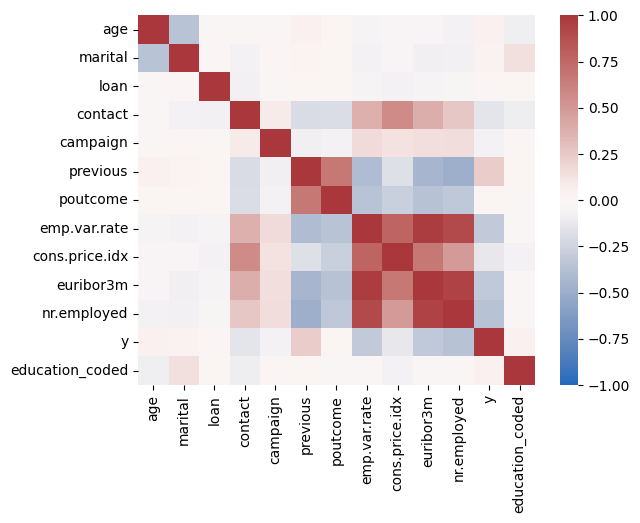

In [ ]:
sns.heatmap(df.corr(numeric_only=True), vmin=-1, vmax=1, cmap="vlag");

- Красные квадратики показывают положительную корреляцию, Чем ярче - тем сильнее (+) корреляция
- Синие квадратики отражают негативную корреляцию, Чем ярче - тем сильнее (-) корреляция
- Белые / тусклые красные или синие цвета говорят, что корреляция слабая

### Доп параметры

Можно указывать аннотацию - добавлять значения корреляции на график. (https://seaborn.pydata.org/examples/spreadsheet_heatmap.html)

По умолчанию добавляются с округлением до 4 знака после запятой. Если признаков много - получится нечитаемое:

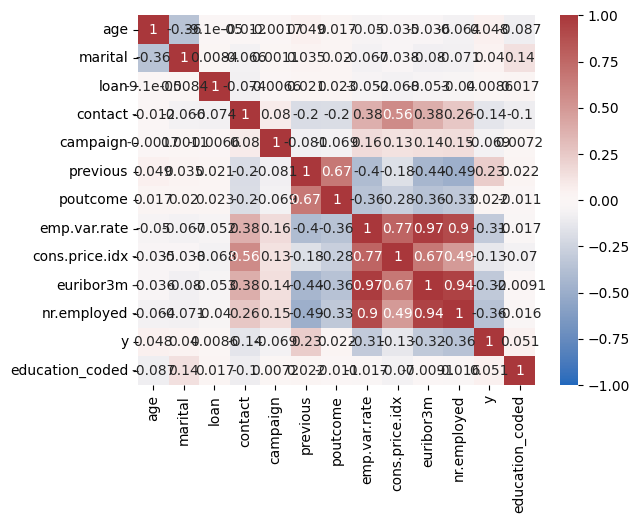

In [30]:
sns.heatmap(df.corr(numeric_only=True), vmin=-1, vmax=1, cmap="vlag", annot=True);

Нам нужно уменьшить шрифт, которым пишем значения корреляции (https://stackoverflow.com/questions/71142600/how-to-use-the-parameter-annot-kws-of-the-function-sns-heatmap-to-revise-the):

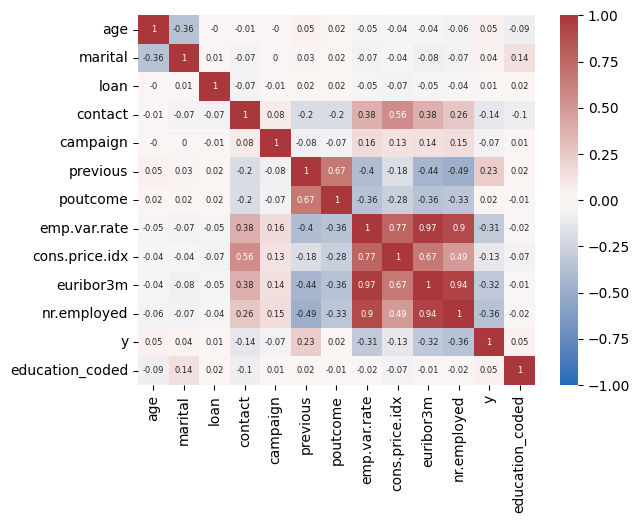

In [ ]:
sns.heatmap(
    df.corr(numeric_only=True).round(2),  # explicit округляем до 2 знака
    vmin=-1,
    vmax=1,
    cmap="vlag",
    annot=True,
    annot_kws={"size": 6},  # размер шрифта в ячейках
);

Из-за этого стало хуже разрешение. Чтобы изменить размер графика, нужно использовать библиотеку `matplotlib` (и менять размер шрифта тогда не обязательно)

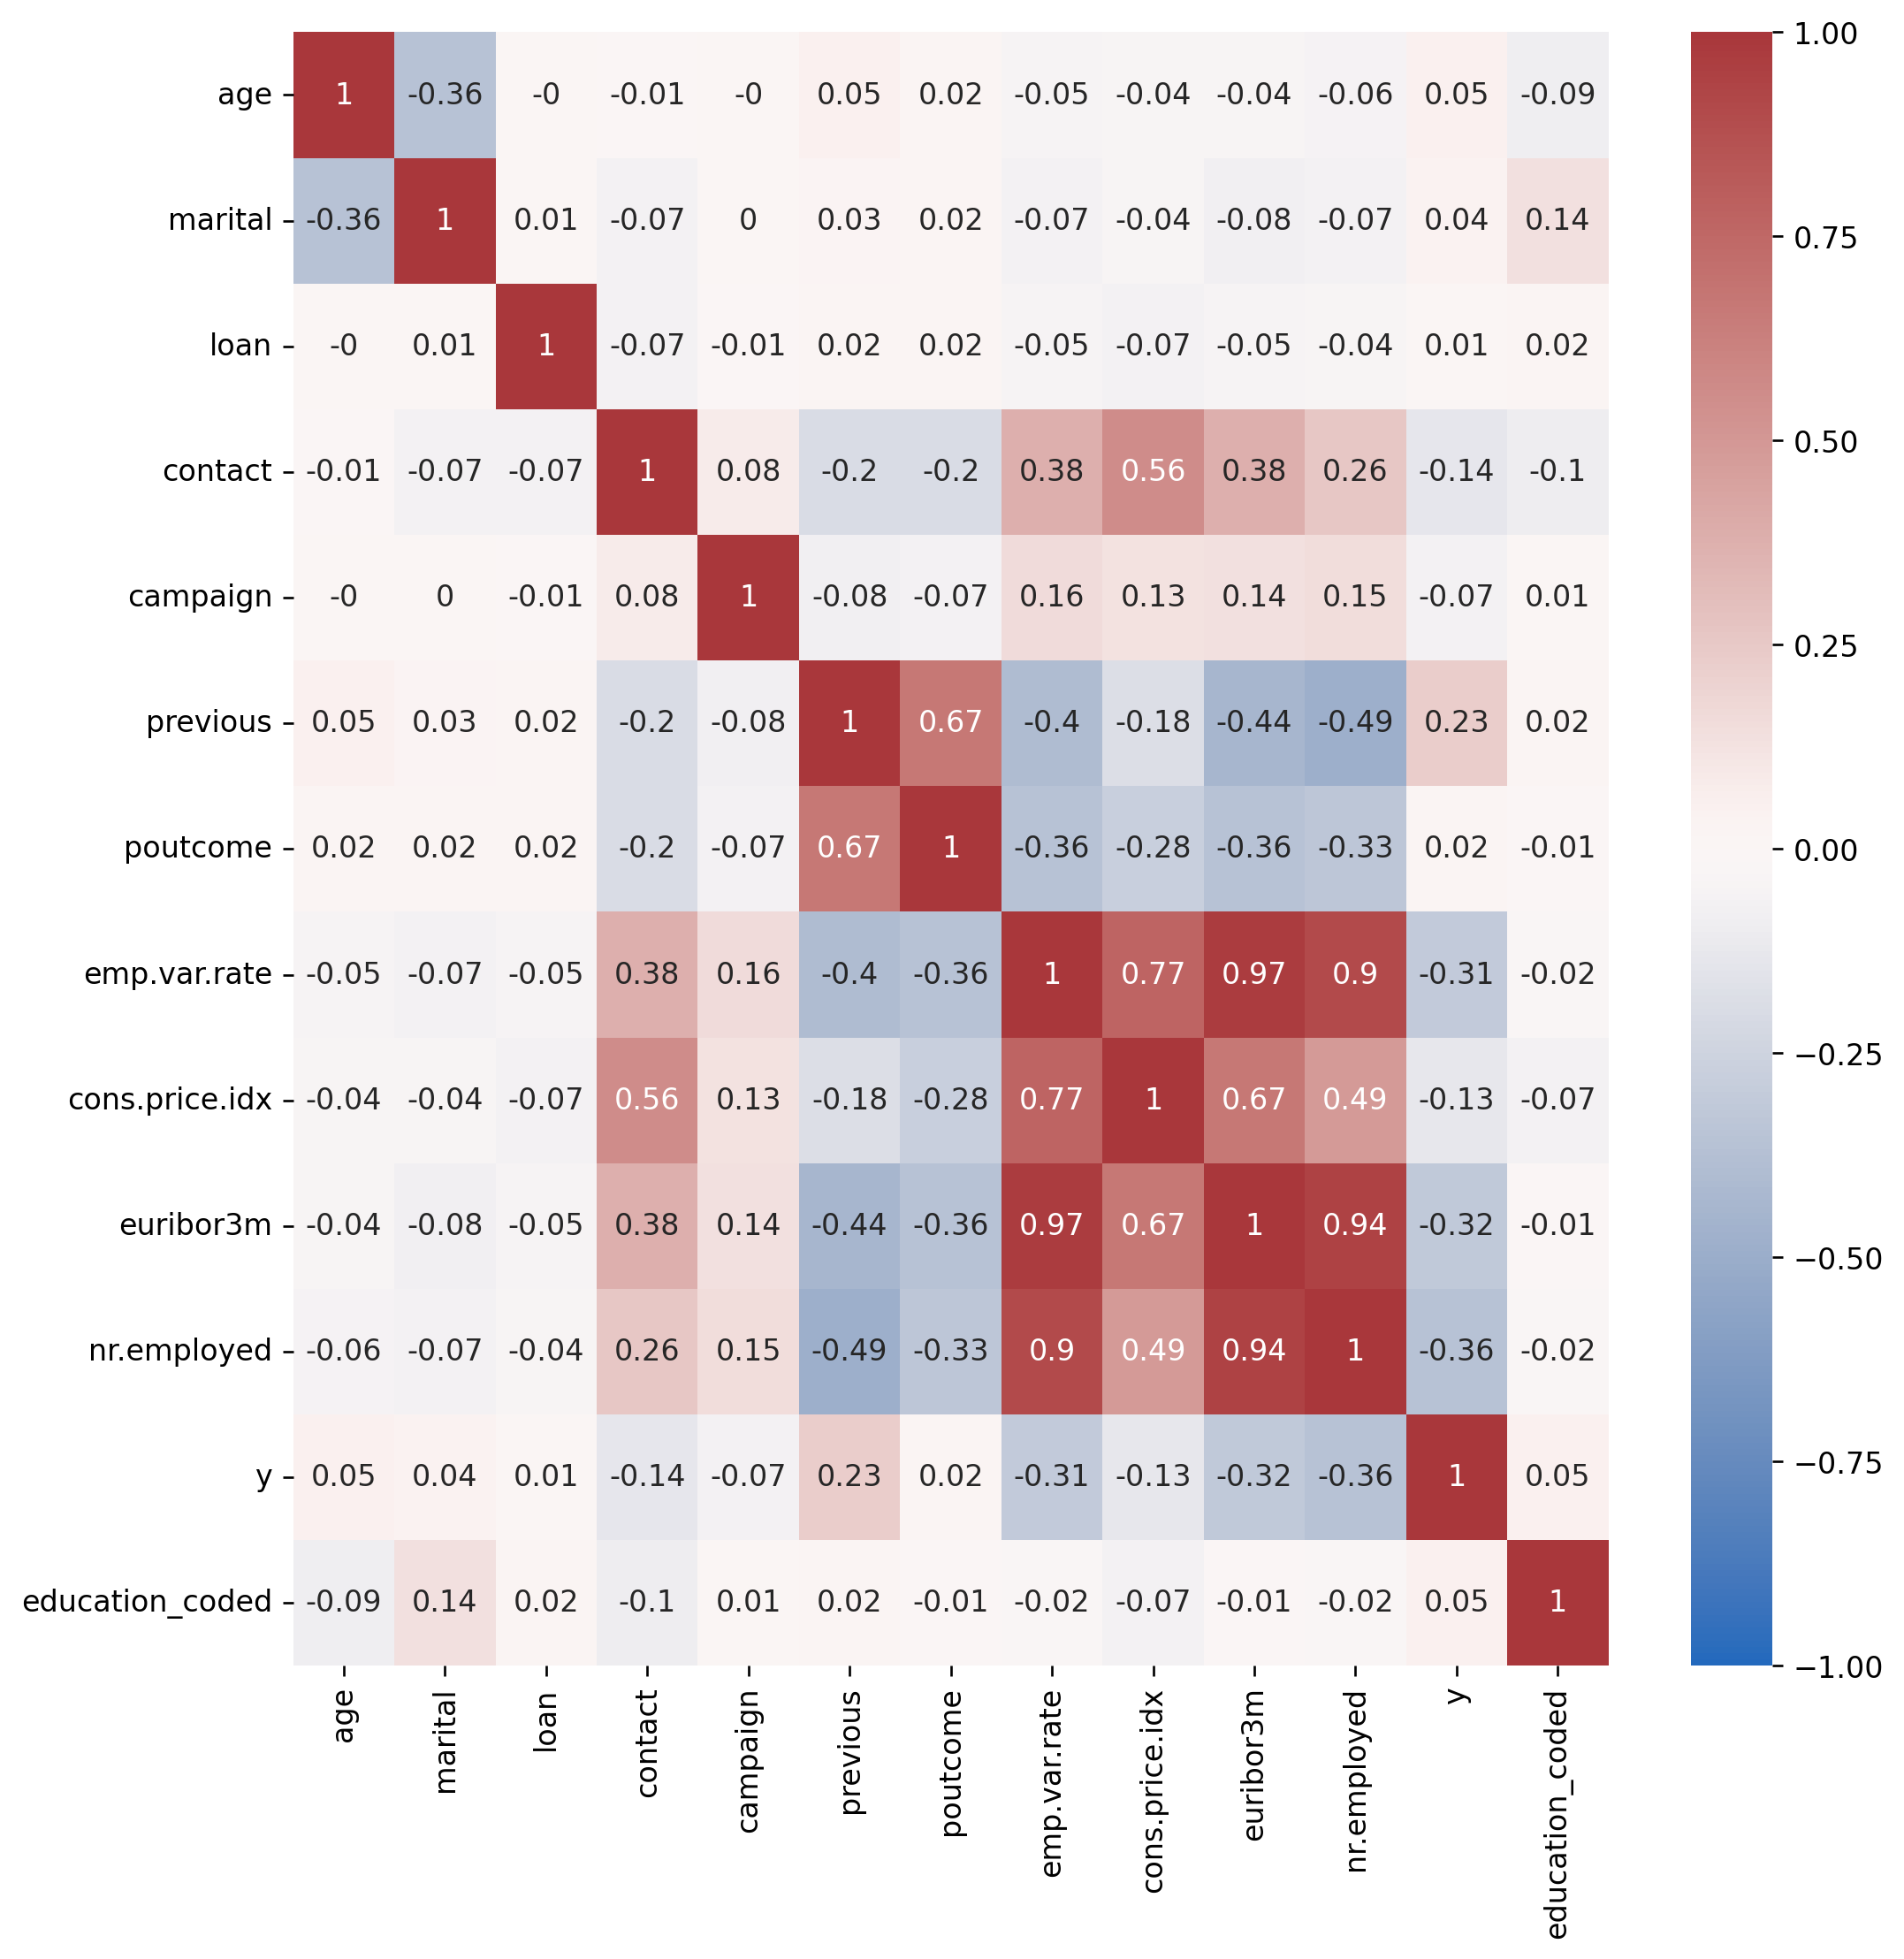

In [40]:
import matplotlib.pyplot as plt

# figsize=(WIDTH, HEIGHT)
# dpi = разрешение
plt.figure(figsize=(10, 10), dpi=240)

sns.heatmap(
    df.corr(numeric_only=True).round(2),  # explicit округляем до 2 знака
    vmin=-1,
    vmax=1,
    cmap="vlag",
    annot=True,
);

Как и говорилось ранее, матрица является симметричной. Половина значений из нее не нужны: нижний треугольник является зеркалом верхнего, а диагональ вообще неинформативна, там только автокорреляция.

Чтобы отобразить только "треугольник" корреляций (уникальные значения корреляций), используем (https://seaborn.pydata.org/examples/many_pairwise_correlations.html):

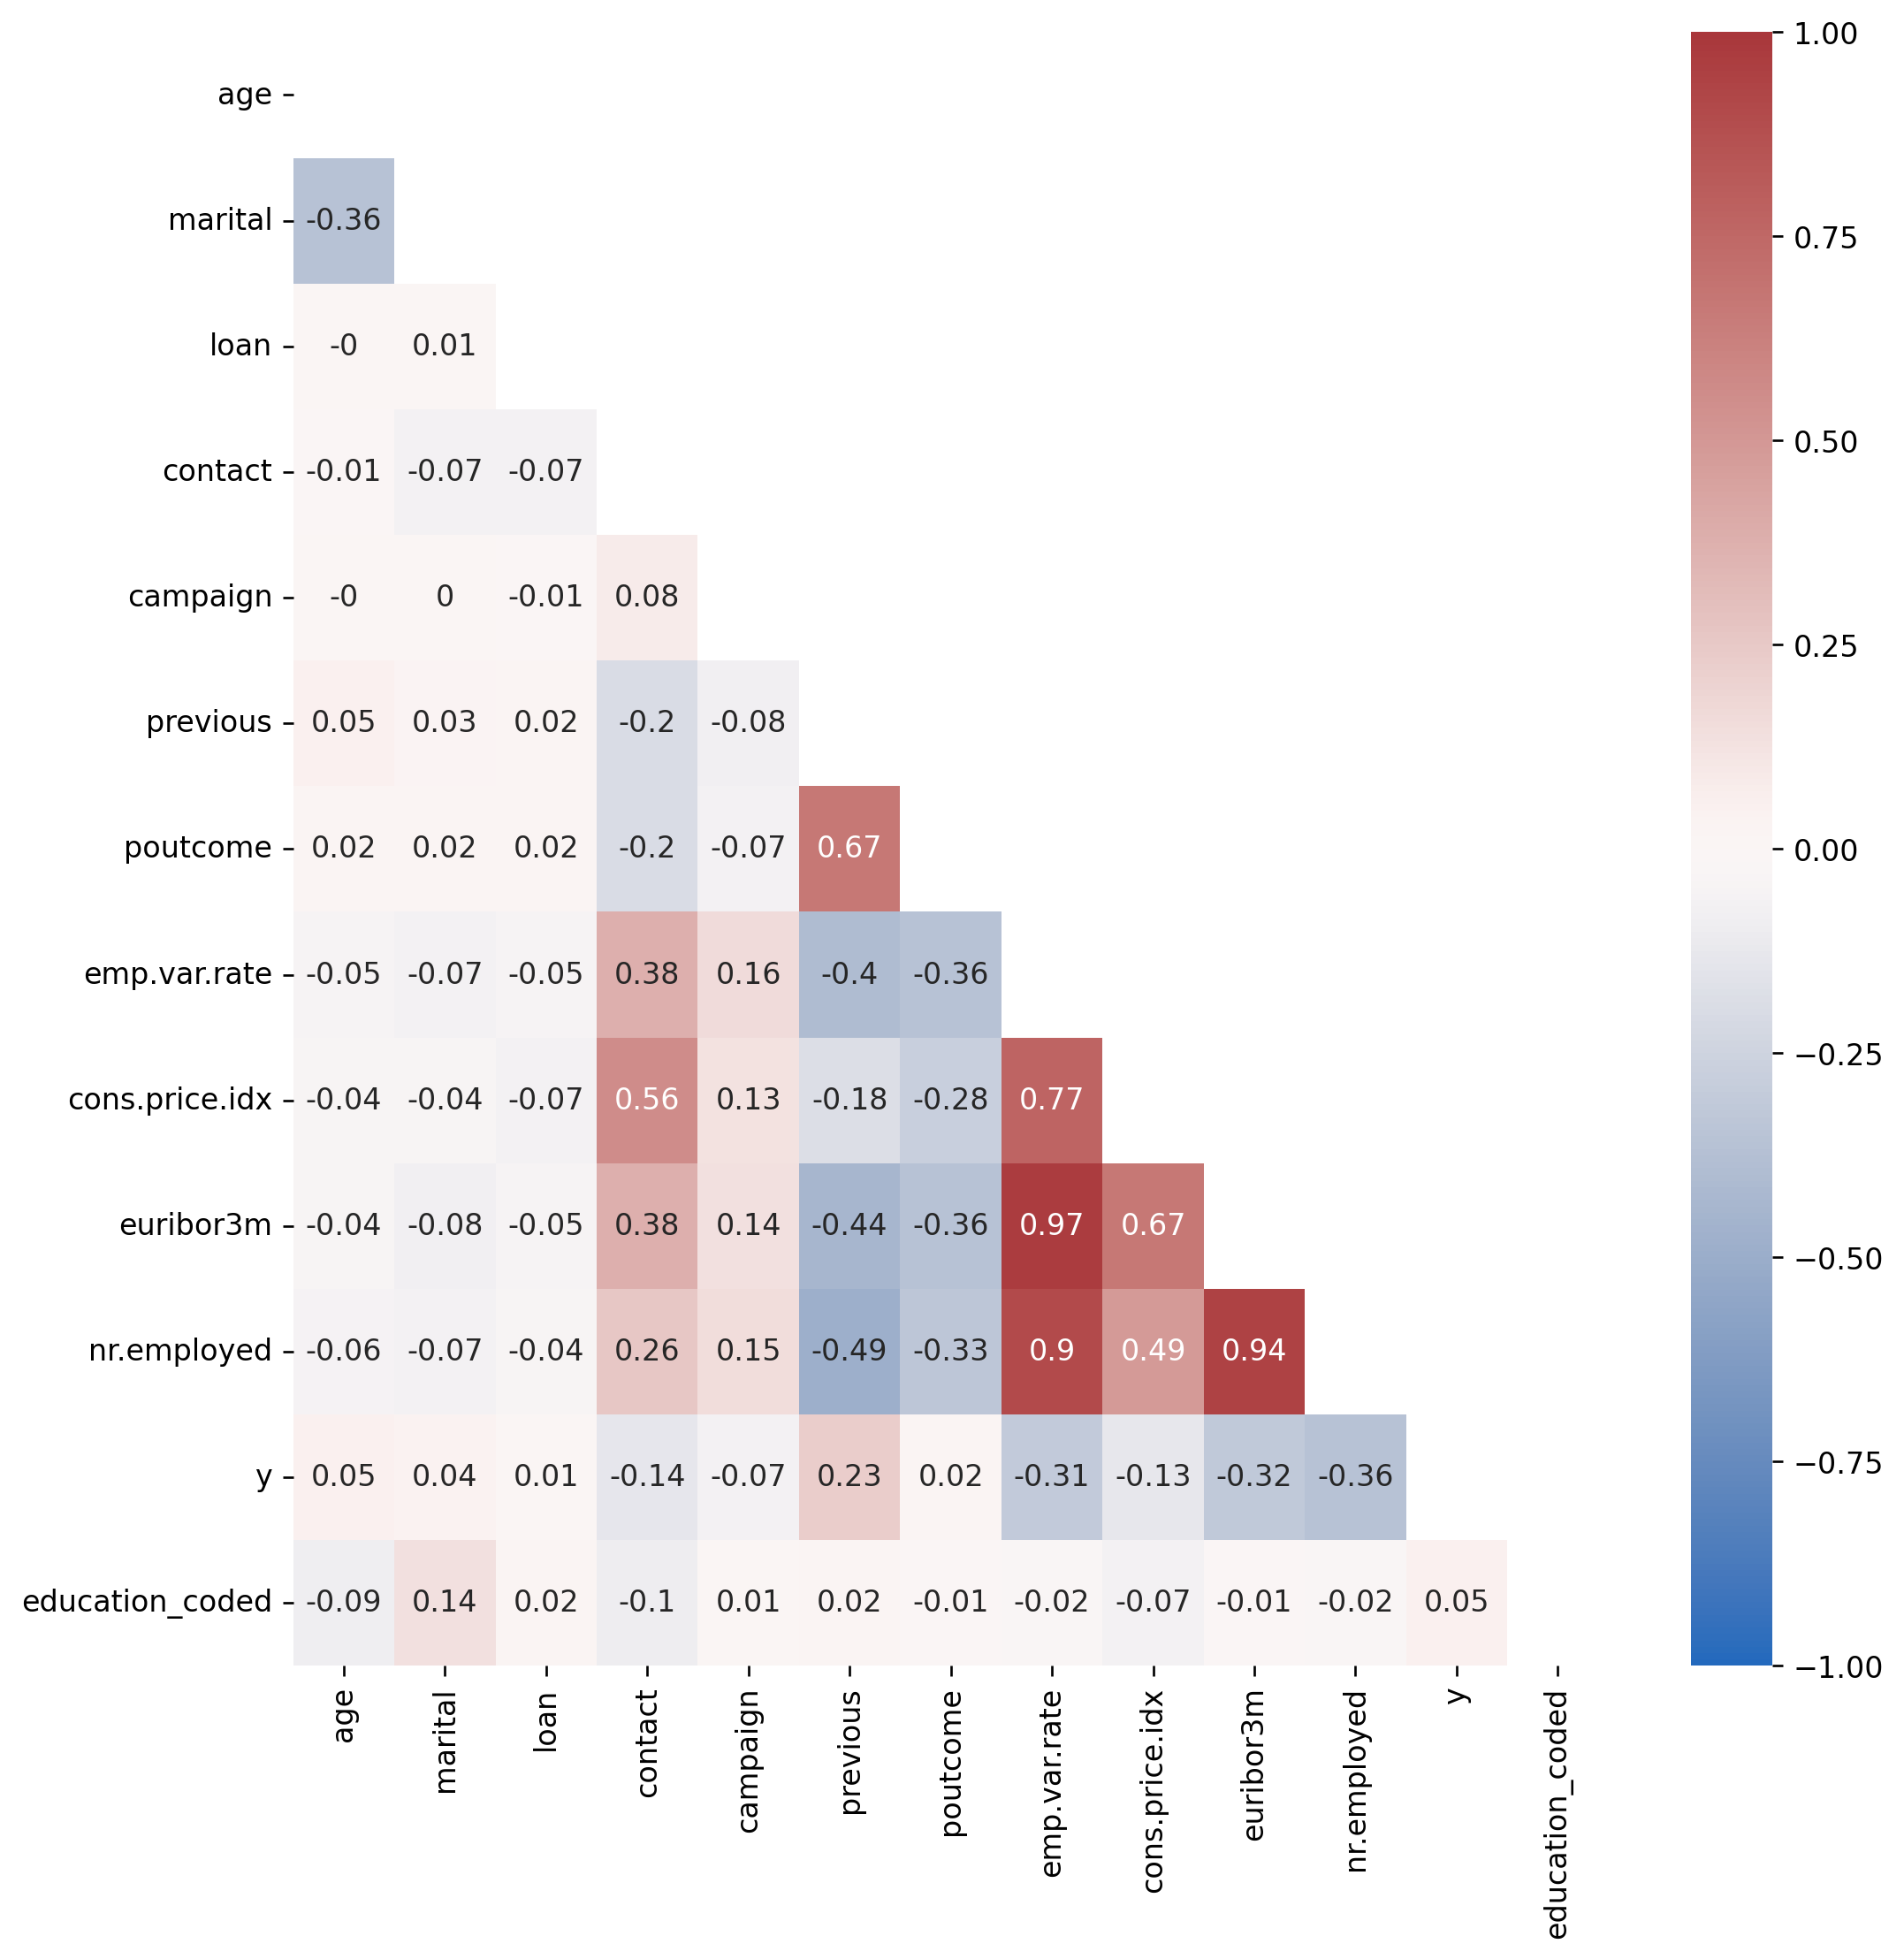

In [ ]:
import numpy as np

plt.figure(figsize=(10, 10), dpi=240)

corr_df = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(corr_df.round(2), vmin=-1, vmax=1, cmap="vlag", annot=True, mask=mask);